In [1]:
!pip install pandas numpy nltk scikit-learn imbalanced-learn gdown tensorflow emoji

In [2]:
import numpy as np
import pandas as pd
import re
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

2026-04-10 16:53:04.525212: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775839984.717002      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775839984.777751      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775839985.255809      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775839985.255849      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775839985.255851      24 computation_placer.cc:177] computation placer alr

<h1>Loading the data and checking the shape</h1>


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/klokeshnaidu/dataset/Mental-health-related-subreddits.csv")

display(df.head())
print(df.shape)

/tmp/ipykernel_24/80095425.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/klokeshnaidu/dataset/Mental-health-related-subreddits.csv")


,Title,Text,Subreddit,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78
0,exposure does not work!,I have struggled with social anxiety from chil...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Panic attack? derealization? can't go to docto...,"Back in March (I know, a while ago D:), I woke...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,How long can a panic attack last?!,I've been withdrawing from medicines lately (e...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Stepping stones,"First time poster, long time lurker. \n\nI've ...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Coping with anxiety over climate change, on th...","Hi all,\n\nI made a throwaway account as my ma...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(488738, 79)


In [4]:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

In [5]:
print(df.shape)
print(df.columns)
df.info()

(488738, 3)
Index(['Title', 'Text', 'Subreddit'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488738 entries, 0 to 488737
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Title      488608 non-null  object
 1   Text       488573 non-null  object
 2   Subreddit  488535 non-null  object
dtypes: object(3)
memory usage: 11.2+ MB


In [6]:
df = df.dropna()

print(df.isnull().sum())

Title        0
Text         0
Subreddit    0
dtype: int64


In [7]:
valid_labels = [
    "depression",
    
    "Anxiety",
    "bipolar",
    "BPD",
    "schizophrenia",
    "autism"
]

# normalize text (very important)
df["Subreddit"] = df["Subreddit"].astype(str).str.strip()

# keep only valid labels
df = df[df["Subreddit"].isin(valid_labels)]

df = df[df["Subreddit"] != "mentalhealth"]

df["Subreddit"].value_counts()

Subreddit
depression       258490
Anxiety           86242
bipolar           41490
BPD               38210
schizophrenia     17505
autism             7142
Name: count, dtype: int64

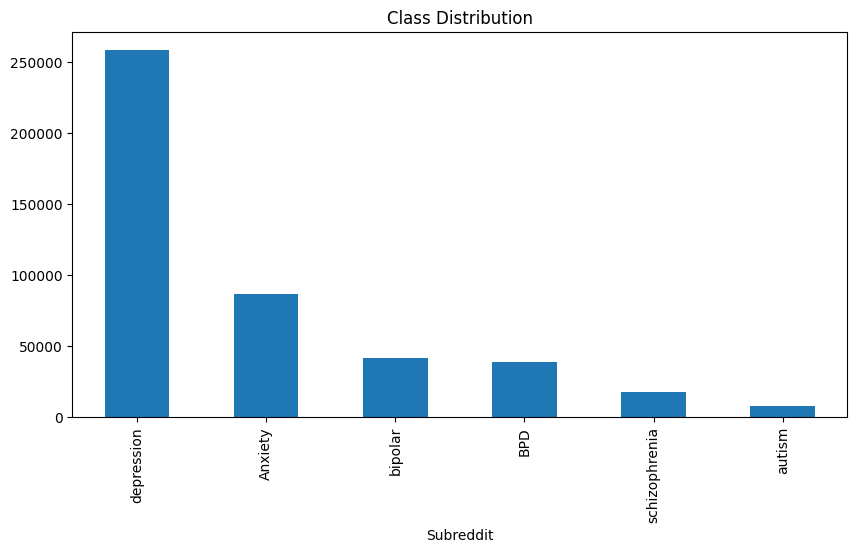

In [8]:
import matplotlib.pyplot as plt

df["Subreddit"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Class Distribution")
plt.show()

<h3>Text Length Analysis</h3>

In [9]:
df["text_length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["text_length"].describe()

count    449079.000000
mean        184.987488
std         224.415564
min           0.000000
25%          60.000000
50%         121.000000
75%         229.000000
max        6597.000000
Name: text_length, dtype: float64

🚨 Key Observations
1️⃣ Highly Skewed Distribution

👉 Most posts are short-medium (50–300 words)

👉 Few extremely long posts → outliers

3️⃣ Long tail problem

👉 Posts with:  

1000+ words

7000+ words

❌ These add noise
❌ Increase TF-IDF sparsity
❌ Hurt Naive Bayes performance

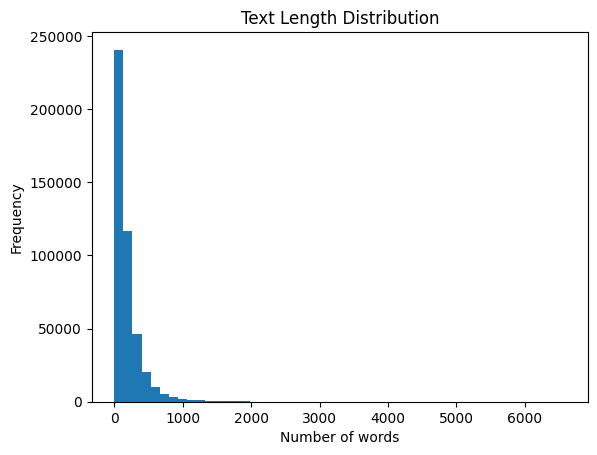

In [10]:
import matplotlib.pyplot as plt

plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

🎯 Decision (VERY IMPORTANT)

For Naive Bayes, we will:

✔️ Remove empty texts

✔️ Limit max text length (trim very long posts)

<h3>Removing the Posts with 0 words</h3>

In [11]:
df = df[df["text_length"] > 0]
print(df.shape)

(449000, 4)


<h3>Triming the long text</h3>

In [12]:
def trim_text(text, max_words=500):
    words = text.split()
    return " ".join(words[:max_words])

df["Text"] = df["Text"].apply(trim_text)
df.shape

(449000, 4)

<h3>Merge Title + Text</h3>

In [13]:
df["content"] = df["Title"] + " " + df["Text"]

<h3>Clean Text</h3>

In [14]:
import re

def clean_text(text):
    text = str(text).lower()  # Convert to string before applying lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["content"].apply(clean_text)

In [15]:
df["clean_text"]

0         exposure does not work i have struggled with s...
1         panic attack derealization cant go to doctors ...
2         how long can a panic attack last ive been with...
3         stepping stones first time poster long time lu...
4         coping with anxiety over climate change on the...
                                ...                        
488733    religion and paranoid conversation ok ive got ...
488734    isnt this a little weird for being tardive dys...
488735    is this a symptom of schizophrenia or somethin...
488736    anyone seen the new black mirror episode bande...
488737    my girlfriend of over year and i just broke up...
Name: clean_text, Length: 449000, dtype: object

<h3>Remove Stopwords</h3>

In [16]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [17]:
df["clean_text"].head()

0    exposure does work struggled social anxiety ch...
1    panic attack derealization doctors advice appr...
2    long panic attack ive withdrawing medicines la...
3    stepping stones time poster long time lurker i...
4    coping anxiety climate change verge considerin...
Name: clean_text, dtype: object

In [18]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['Subreddit'])

X = df['clean_text']
y = df['label_enc']

num_classes = len(le.classes_)
print(le.classes_)

['Anxiety' 'BPD' 'autism' 'bipolar' 'depression' 'schizophrenia']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
max_words = 30000
max_len = 150

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [21]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.8678340871313155), 1: np.float64(1.9591801114856389), 2: np.float64(10.484530064214828), 3: np.float64(1.8039735631491192), 4: np.float64(0.2895438555762987), 5: np.float64(4.275885055829345)}


In [22]:
model = Sequential()

# Embedding
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

# CNN layers
model.add(Conv1D(128, 5, activation='relu'))
model.add(BatchNormalization())

model.add(Conv1D(128, 3, activation='relu'))
model.add(GlobalMaxPooling1D())

# Dense
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

# Compile
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1775840119.026904      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775840119.033086      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10


I0000 00:00:1775840121.754444      76 service.cc:152] XLA service 0x7b6754005bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775840121.754493      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775840121.754498      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775840122.259312      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-10 16:55:24.411330: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.2 = (f32[64,128,1,146]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,1,144]{3,2,1,0} %bitcast.5534, f32[128,128,1,3]{3,2,1,0} %bitcast.5035), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/sequential_1/conv1d_1_2/convolution/Conv2DBackpropInput" source_file="/u

  27/4490 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.1546 - loss: 2.2656

I0000 00:00:1775840131.972379      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4490/4490 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - accuracy: 0.5530 - loss: 1.1386 - val_accuracy: 0.7026 - val_loss: 0.9503
Epoch 2/10
4490/4490 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.7386 - loss: 0.7223 - val_accuracy: 0.7195 - val_loss: 0.8625
Epoch 3/10
4490/4490 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.7660 - loss: 0.5974 - val_accuracy: 0.7420 - val_loss: 0.7787
Epoch 4/10
4490/4490 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.7890 - loss: 0.4992 - val_accuracy: 0.7609 - val_loss: 0.7437
Epoch 5/10
4490/4490 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.8037 - loss: 0.4295 - val_accuracy: 0.7139 - val_loss: 0.8622
Epoch 6/10
4490/4490 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.8228 - loss: 0.3616 - val_accuracy: 0.7318 - val_loss: 0.8151
Epoch 7/10
4490/4490 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.8380 - loss: 0.3138 - val_accuracy: 0.7479 - val_loss: 0.8694
Epoch 8/10
4490/4490 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.8553 - loss: 0.2720 - val

In [24]:
y_pred = model.predict(X_test_pad)
y_pred = y_pred.argmax(axis=1)

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [25]:
classes = np.unique(y_test)

print("Accuracy for each class:\n")

for cls in classes:
    y_true_bin = (y_test == cls).astype(int)
    y_pred_bin = (y_pred == cls).astype(int)

    acc = np.mean(y_true_bin == y_pred_bin)
    print(f"{le.classes_[cls]}: {acc:.4f}")

print("\nF1-score :\n")
print("   Class      Non-Class F1    Class F1")

for cls in classes:
    y_true_bin = (y_test == cls).astype(int)
    y_pred_bin = (y_pred == cls).astype(int)

    f1_class = f1_score(y_true_bin, y_pred_bin)
    f1_non_class = f1_score(1 - y_true_bin, 1 - y_pred_bin)

    print(f"{le.classes_[cls]:12} {f1_non_class:.6f}    {f1_class:.6f}")

Accuracy for each class:

Anxiety: 0.9048
BPD: 0.9213
autism: 0.9900
bipolar: 0.9226
depression: 0.8164
schizophrenia: 0.9526

F1-score :

   Class      Non-Class F1    Class F1
Anxiety      0.941271    0.749112
BPD          0.956539    0.582250
autism       0.994913    0.709197
bipolar      0.956957    0.617822
depression   0.797085    0.832437
schizophrenia 0.975045    0.525412


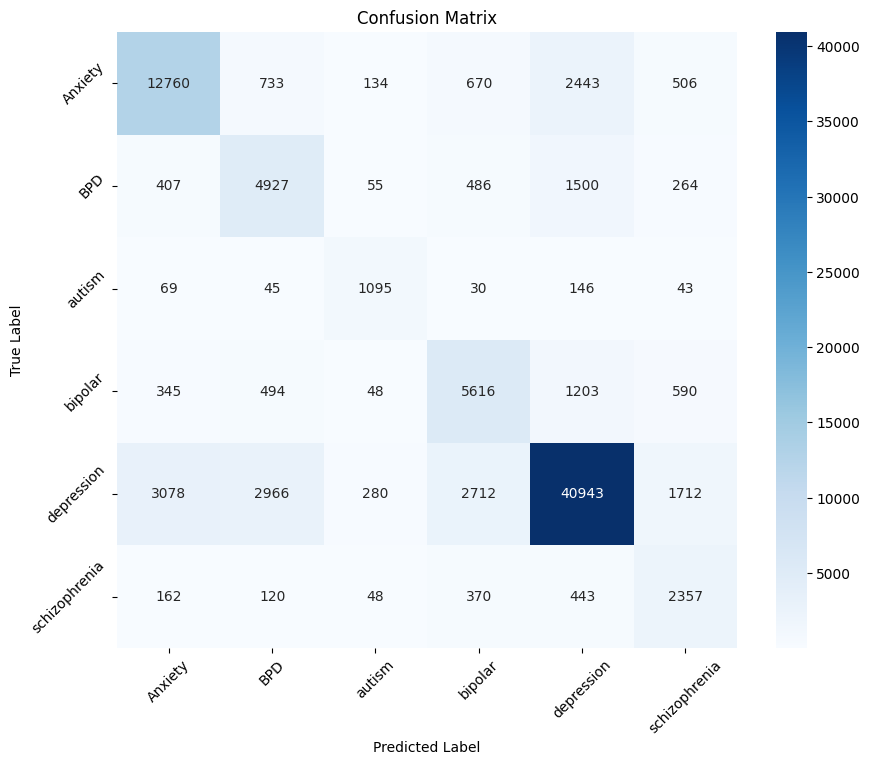

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class names
labels = le.classes_

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.show()

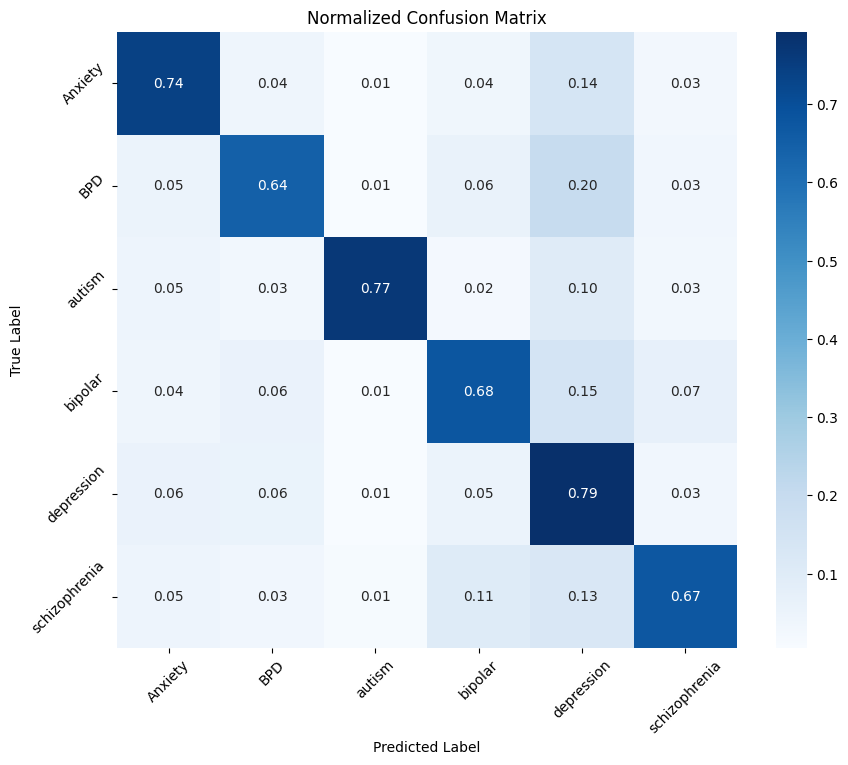

In [27]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.show()

In [28]:
from sklearn.metrics import accuracy_score

# Overall Accuracy
overall_acc = accuracy_score(y_test, y_pred)

print(f"Overall Accuracy: {overall_acc:.4f}")

Overall Accuracy: 0.7539
